In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedMultivariateNormalNLL, TruncatedMultivariateNormalScore, rejection_sampling

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from torch.distributions import MultivariateNormal

In [197]:
# === Function to compute loss for a given μ and σ ===
def trunc_nll(mu, Sigma, data, known_cov=False):
    mu = mu
    T = ch.inverse(Sigma)
    v = T @ mu
    params = ch.cat([T.flatten(), v])
    params.requires_grad = True
    loss = TruncatedMultivariateNormalNLL.apply(
        params, data, phi, dims, TruncatedMultivariateNormalScore(known_cov=known_cov), None, 100000
    )
    loss.backward()
    return loss.item(), list(params.grad)


def trunc_loss_breakdown(mu, Sigma, data, known_cov=False):
        mu = mu
        T = ch.inverse(Sigma)
        v = T @ mu
        params = ch.cat([T.flatten(), v])
        T_flat = params[:dims * dims]
        v = params[dims * dims : dims * dims + dims]           # nu (v)
        T = T_flat.view(dims, dims)                            # T = Sigma^{-1}
        # unpack data
        S = data[:, :dims]                                     # observations x (batch, dims)
        S_grad = data[:, dims:] if data.size(1) > dims else None

        # reconstruct Sigma and mu
        sigma = T.inverse()                                    # Sigma
        mu = (sigma @ v).view(dims)                            # mu = Sigma @ v
        L = ch.linalg.cholesky(sigma)
        
        s, p_hat = rejection_sampling(mu, sigma, phi, dims, 1000000)
        # estimate probability of being in truncation region
        # p_hat = mask.float().mean(dim=0).clamp_min(eps)
        # compute the standard (unnormalized) negative log likelihood first two terms:
        # nll_i = 0.5 * x^T T x - x^T v
        # vectorized:
        xT_T = (S @ T)                # (batch, dims)
        quad = 0.5 * (xT_T * S).sum(dim=1)   # (batch,)
        linear = (S @ v)                     # (batch,)
        nll = quad - linear                  # (batch,)

        # Now compute log integral (log I) correctly using derivation:
        # log I = 0.5 * mu^T T mu + 0.5 * d * log(2*pi) + 0.5 * log|Sigma| + log P(Z in S)
        # where P(Z in S) is probability under N(mu, Sigma) that Z in truncation region.
        # note: mu^T T mu = mu^T v   (since v = T mu)
        muT_T_mu = (mu @ v) * 0.5                  # scalar
        const_term = 0.5 * dims * math.log(2 * math.pi)
        # logdet(Sigma) = - logdet(T)
        # compute logdet(T) robustly
        # If T is symmetric positive definite, ch.logdet(T) is fine.
        logdet_T = ch.logdet(T)                    # scalar tensor
#         logdet_sigma = -logdet_T                   # scalar tensor

        # p_hat may be zero for some observations -> use eps
        # p_hat shape is (batch,)
        # log_p_hat = ch.log(p_hat + eps)            # avoid -inf
        log_p_hat = ch.log(p_hat + 1e-12)
        logdet_sigma = 2 * ch.log(ch.diagonal(L)).sum()


        # assemble log integral per batch
        # muT_T_mu is a scalar; convert to tensor same device
        muT_T_mu_t = muT_T_mu.to(logdet_sigma.device)

        log_I = muT_T_mu_t + const_term + 0.5 * logdet_sigma + log_p_hat  # (batch,)

        # final per-sample negative log-likelihood:
        # ell = 0.5 x^T T x - x^T v + log I
        return nll.mean(), muT_T_mu_t, const_term, 0.5 * logdet_sigma, -log_p_hat

In [201]:
import math 

M = MultivariateNormal(ch.zeros(1), ch.eye(1))
NUM_SAMPLES = 10000
SAMPLES = M.sample([NUM_SAMPLES])


def rejection_sampling(mu, sigma, phi, dims, num_samples=10000): 
    M = MultivariateNormal(ch.zeros(dims), ch.eye(dims))
    L = ch.linalg.cholesky(sigma)

    accepted_samples = ch.Tensor([])
    num_sampled = 0

    while accepted_samples.size(0) < num_samples:
        # draw samples per-observation so phi can depend on each sample individually if needed
#         samples = M.sample((num_samples,))  # -> (num_samples, dims) 
#         print(f'accepted samples: {accepted_samples.size(0)}')
#         print(f'mu: {mu}')
#         print(f'sigma: {sigma}')
        samples = SAMPLES
        s = mu + samples @ L.T 
        mask = phi(s)
#         import pdb; pdb.set_trace()
#         print(f'mask: {mask}')
        accepted_samples = ch.cat([accepted_samples, s[mask.nonzero()[:,0]]])
        num_sampled += NUM_SAMPLES

    p_hat = ch.Tensor([accepted_samples.size(0) / num_sampled])
    if p_hat < .01:
        print(f'acceptance rate: {p_hat.item()}')

    return accepted_samples, p_hat

class TruncatedMultivariateNormalNLL(ch.autograd.Function):
    """
    Computes the truncated negative population log likelihood for truncated multivariate normal distribution with known truncation. 
    Function calculates the truncated negative log likelihood in the forward method and then calculates the 
    gradients with respect mu and cov in the backward method. When sampling from the conditional distribution, 
    we sample batch_size * num_samples samples, we then filter out the samples that remain in the truncation set, 
    and retainup to batch_size of the filtered samples. If there are fewer than batch_size number of samples remain,
    we provide a vector of zeros and calculate the untruncated log likelihood. 
    """
    @staticmethod
    def forward(ctx, params, data, phi, dims, trunc_multi_norm_score, num_samples=1000, eps=1e-12):
        """
        Corrected forward for truncated Gaussian negative log-likelihood.

        Args:
            params (torch.Tensor): vector containing flattened T (dims^2) then v (dims)
            data (torch.Tensor): batch_size x (dims + gradsize) where first dims are x
            phi (callable): oracle function that takes samples shape (..., dims) and returns boolean mask of same leading shape
            dims (int): dimensionality d
            censored_sample_nll: saved for ctx (kept for compatibility)
            hessian: optional object with save_samples method
            num_samples (int): number of MC samples per observation (increase for better estimates)
            eps (float): small value to avoid log(0)
        Returns:
            scalar tensor: mean negative log-likelihood over batch
        """
        # unpack params
        T_flat = params[:dims * dims]
        v = params[dims * dims : dims * dims + dims]           # nu (v)
        T = T_flat.view(dims, dims)                            # T = Sigma^{-1}
        # unpack data
        S = data[:, :dims]                                     # observations x (batch, dims)
        S_grad = data[:, dims:] if data.size(1) > dims else None

        # reconstruct Sigma and mu
        sigma = T.inverse()                                    # Sigma
        mu = (sigma @ v).view(dims)                            # mu = Sigma @ v
        L = ch.linalg.cholesky(sigma)

        s, p_hat = rejection_sampling(mu, sigma, phi, dims, 1000000)
        # estimate probability of being in truncation region
        # p_hat = mask.float().mean(dim=0).clamp_min(eps)
        # compute the standard (unnormalized) negative log likelihood first two terms:
        # nll_i = 0.5 * x^T T x - x^T v
        # vectorized:
        xT_T = (S @ T)                # (batch, dims)
        quad = 0.5 * (xT_T * S).sum(dim=1)   # (batch,)
        linear = (S @ v)                     # (batch,)
        nll = quad - linear                  # (batch,)

        # Now compute log integral (log I) correctly using derivation:
        # log I = 0.5 * mu^T T mu + 0.5 * d * log(2*pi) + 0.5 * log|Sigma| + log P(Z in S)
        # where P(Z in S) is probability under N(mu, Sigma) that Z in truncation region.
        # note: mu^T T mu = mu^T v   (since v = T mu)
        muT_T_mu = (mu @ v) * 0.5                  # scalar
        const_term = 0.5 * dims * math.log(2 * math.pi)
        # logdet(Sigma) = - logdet(T)
        # compute logdet(T) robustly
        # If T is symmetric positive definite, ch.logdet(T) is fine.
        logdet_T = ch.logdet(T)                    # scalar tensor
        logdet_sigma = -logdet_T                   # scalar tensor

        # p_hat may be zero for some observations -> use eps
        # p_hat shape is (batch,)
        # log_p_hat = ch.log(p_hat + eps)            # avoid -inf
        log_p_hat = ch.log(p_hat + eps)
        logdet_sigma = 2 * ch.log(ch.diagonal(L)).sum()


        # assemble log integral per batch
        # muT_T_mu is a scalar; convert to tensor same device
        muT_T_mu_t = muT_T_mu.to(logdet_sigma.device)

        log_I = muT_T_mu_t + const_term + 0.5 * logdet_sigma + log_p_hat  # (batch,)

        # final per-sample negative log-likelihood:
        # ell = 0.5 x^T T x - x^T v + log I
        ell = nll + log_I  # (batch,)

        # save for backward if needed
        ctx.trunc_multi_norm_score = trunc_multi_norm_score 
        # save tensors that will be needed in backward (S_grad maybe None)
        ctx.save_for_backward(S_grad, s)
        return ell.mean()
    
    @staticmethod
    def forward(ctx, params, data, phi, dims, trunc_multi_norm_score,
                hessian=None, num_samples=2000, eps=1e-12, crn_eps=None):
        """
        params: tensor of length dims*dims + dims: [T_flat, v]
        data: (batch, dims) observed truncated data (or multiple observations)
        phi: truncation oracle, accepts (..., dims) -> boolean mask
        """
        device = params.device
        dtype = params.dtype

        # --- unpack ---
        T_flat = params[:dims*dims]
        v = params[dims*dims : dims*dims + dims].view(dims, 1)    # (d,1)
        T = T_flat.view(dims, dims)                              # (d,d)
        # enforce symmetry (optional)
        T = 0.5 * (T + T.t())

        # reconstruct Sigma and mu
        sigma = ch.inverse(T)
        mu = (sigma @ v).view(dims)   # (d,)

        batch_size = data.size(0)

        # --- reparameterized sampling ---
#         # draw base eps ~ N(0, I) once (CRN) unless crn_eps passed
#         if crn_eps is None:
#             z = ch.randn(num_samples, batch_size, dims, device=device, dtype=dtype)
#         else:
#             # user provided base noise to reuse across evaluations (recommended for plotting)
#             z = crn_eps  # shape (num_samples, batch, dims)
        
        z, p_hat = rejection_sampling(mu, sigma, phi, dims, num_samples=10000)

        # cholesky
        L = ch.linalg.cholesky(sigma)   # (d,d)
        s = mu.view(1,1,dims) + (z @ L.t())  # (num_samples, batch, dims)

        # apply phi
#         mask = phi(s)    # boolean of shape (num_samples, batch)
#         p_hat = mask.float().mean(dim=0).clamp_min(eps)  # per-batch (batch,)

        # --- per-observation "untruncated" negative log-likelihood main term ---
        # nll_obs = 0.5 * x^T T x - x^T v
        S = data[:,:dims]
        S_grad = data[:,dims:]
#         S = data.view(batch_size, dims)   # ensure shape
        xT_T = ch.matmul(S, T)            # (batch, dims)
        quad = 0.5 * (xT_T * S).sum(dim=1)    # (batch,)
        linear = (S @ v.view(-1))              # (batch,)
        nll_term = quad - linear               # (batch,)

        # --- normalization / integral term ---
        # mu^T T mu = mu^T v
        muT_v = 0.5 * (mu @ v.view(-1))   # scalar
        d_const = 0.5 * dims * math.log(2.0 * math.pi)

        # logdet(Sigma) via cholesky: logdet(Sigma) = 2 * sum(log(diag(L)))
        logdet_sigma = 2.0 * ch.log(ch.diagonal(L)).sum()

        # truncation correction: subtract log p_hat (per-batch)
        log_p_hat = ch.log(p_hat)  # (batch,)
        # assemble log integral term per batch (broadcast scalar muT_v, d_const, logdet_sigma)
        logI = muT_v + d_const + 0.5 * logdet_sigma - log_p_hat   # (batch,)
#         import pdb; pdb.set_trace()
        ell = nll_term + logI   # (batch,)

        # save for backward (if you implement backward)
        ctx.save_for_backward(S_grad, z)
        ctx.trunc_multi_norm_score = trunc_multi_norm_score

        return ell.mean()
    
    @staticmethod
    def forward(ctx, params, data, phi, dims, trunc_multi_norm_score,
                hessian=None, num_samples=2000, eps=1e-12, crn_eps=None):
        T_flat = params[:dims*dims]
        v = params[dims*dims : dims*dims + dims].view(dims, 1)    # (d,1)
        T = T_flat.view(dims, dims) 
        # reconstruct Sigma and mu
        sigma = ch.inverse(T)
        mu = (sigma @ v).view(dims)   # (d,)
        
        S = data[:, :dims]
        S_grad = data[:, dims:]

        sigma = T.inverse()
        L = ch.linalg.cholesky(sigma)

        # base Gaussian part
        quad = 0.5 * (S @ T * S).sum(dim=1)
        linear = (S @ v)
        base = quad - linear  # (batch,)

        # normalization stuff
        muT_T_mu = 0.5 * (mu @ v)
        const_term = 0.5 * dims * math.log(2 * math.pi)
        logdet_sigma = 2 * ch.log(ch.diagonal(L)).sum()

        # Monte-Carlo truncation probability
        z, p_hat = rejection_sampling(mu, sigma, phi, dims, 100000)
        log_p_hat = ch.log(p_hat + 1e-12)

        log_I = muT_T_mu + const_term + 0.5 * logdet_sigma + log_p_hat

        # final NLL — IMPORTANT PART
        nll = base + log_I
        ctx.save_for_backward(S_grad, z)
        ctx.trunc_multi_norm_score = trunc_multi_norm_score
        return nll.mean()

    @staticmethod
    def backward(ctx, grad_output):
        S_grad, s = ctx.saved_tensors
        return  (-S_grad + ctx.trunc_multi_norm_score(s[:S_grad.size(0)])) / S_grad.size(0), None, None, None, None, None, None, None

# One Dimensional Gaussian

In [202]:
# === Ground truth parameters ===
dims = 1
true_mu = ch.ones(dims)
true_var = ch.eye(dims)
true_T = ch.inverse(true_var)
true_v = true_T @ true_mu

print(f'true mean: {true_mu.tolist()}')
print(f'true covariance: {true_var.tolist()}')

true mean: [1.0]
true covariance: [[1.0]]


Observed mean (x): [[1.274032711982727]]


<IPython.core.display.Javascript object>


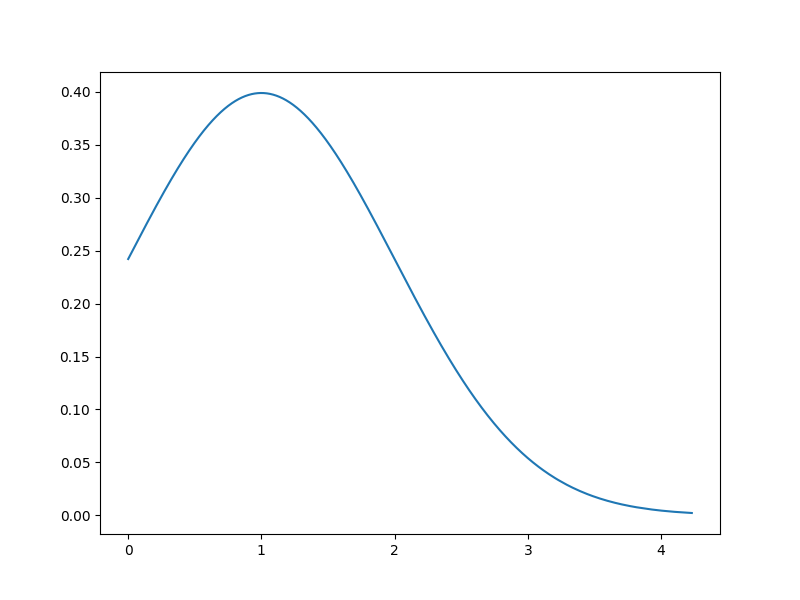

In [203]:
# === Synthetic truncated dataset ===
dist = MultivariateNormal(true_mu, true_var)
samples = dist.sample((5000,))
# Define truncation region: S = {z > 0}
def phi(z):
#     return ch.ones_like(z).bool()
    return (z[..., 0] > 0)
S = samples[phi(samples)]

x_obs = S.mean(0, keepdim=True) # empirical mean as observed sample
print(f"Observed mean (x): {x_obs.tolist()}")

sorted_S = S.sort(dim=0)[0]
pdf = ch.exp(dist.log_prob(sorted_S))

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(sorted_S, pdf)

calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...
calc 20 losses...


<IPython.core.display.Javascript object>


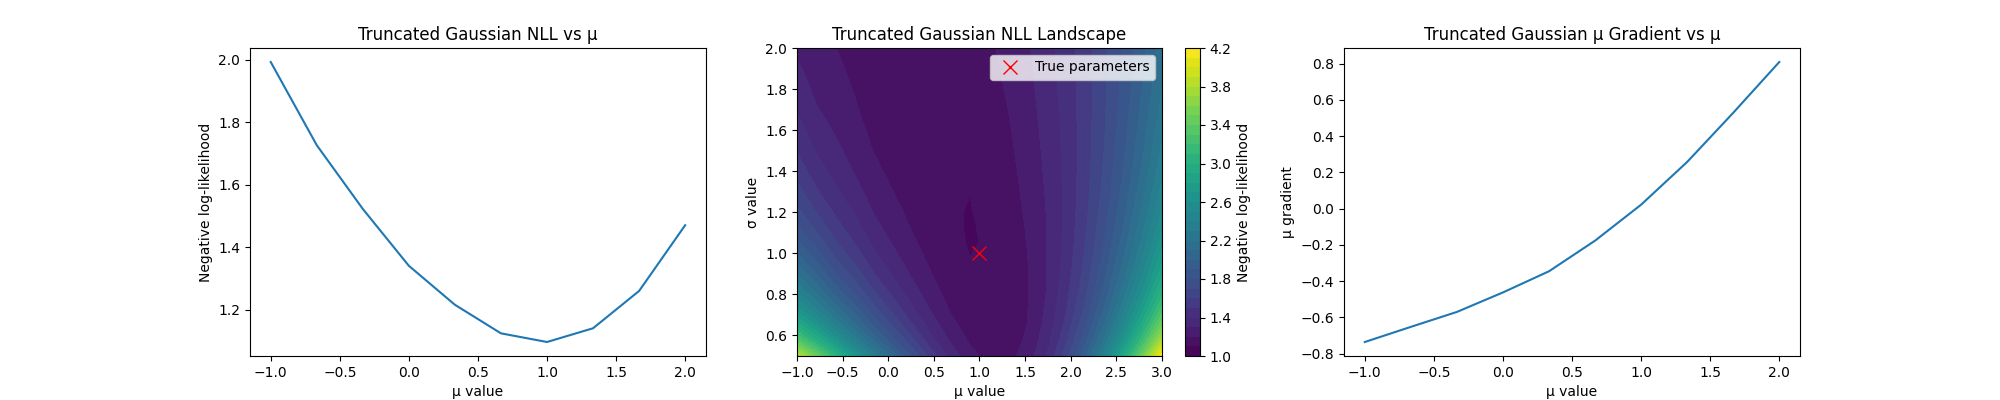

In [204]:
# === Parameter grids ===
mu_values = ch.linspace(-1.0, 3.0, 20)
sigma_values = ch.linspace(0.5, 2.0, 20)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

# DATA 
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=True)
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        var = ch.Tensor([[SIGMA[i, j]]])
        loss, grad = trunc_nll(MU[i, j][...,None], var, data, known_cov=True)
        Z[i, j] = loss

# === Plot the loss landscape ===
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 4))

mus = ch.linspace(-1, 2, 10)
losses = [trunc_nll(ch.tensor([m]), true_var, data)[0] for m in mus]

ax1.plot(mus, losses)
ax1.set_xlabel("μ value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Gaussian NLL vs μ")

cp = ax2.contourf(MU, SIGMA, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax2, label="Negative log-likelihood")

ax2.set_title("Truncated Gaussian NLL Landscape")
ax2.set_xlabel("μ value")
ax2.set_ylabel("σ value")

# mark the ground truth
ax2.plot(true_mu.item(), true_var.sqrt().item(), 'rx', markersize=10, label="True parameters")
ax2.legend()
    
mu_grads = [trunc_nll(ch.tensor([m]), true_var, data, known_cov=True)[1][1] for m in mus]

ax3.plot(mus, mu_grads)
ax3.set_xlabel("μ value")
ax3.set_ylabel("μ gradient")
ax3.set_title("Truncated Gaussian μ Gradient vs μ")


plt.show()

<IPython.core.display.Javascript object>


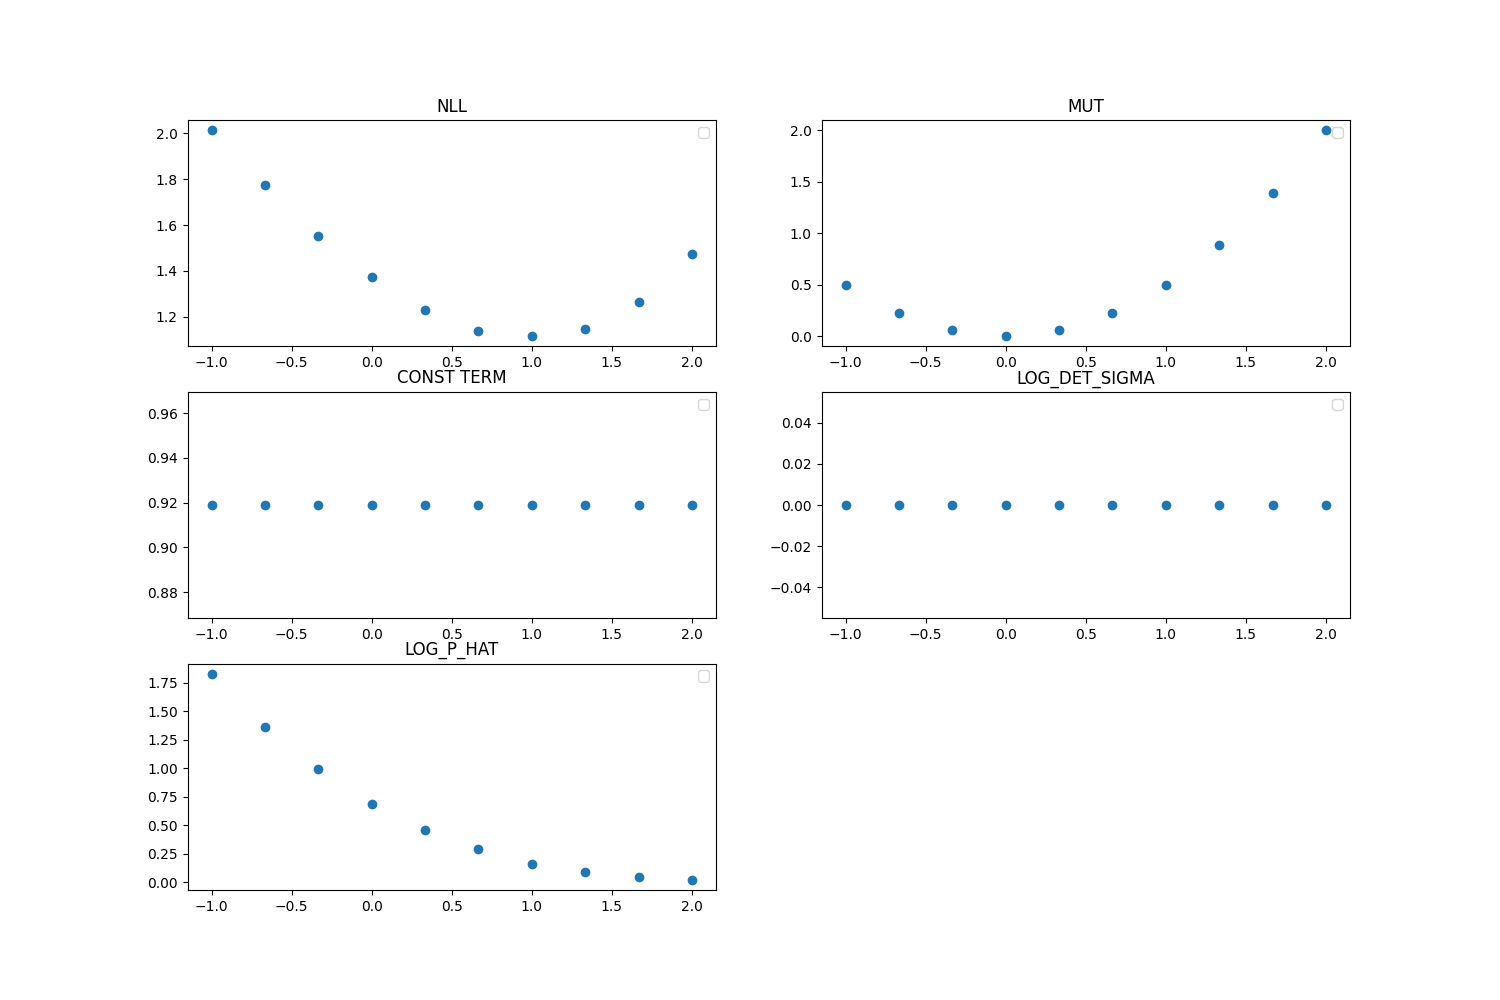

/tmp/ipykernel_73367/3343825002.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_73367/3343825002.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_73367/3343825002.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()
/tmp/ipykernel_73367/3343825002.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()
/tmp/ipykernel_73367/3343825002.py:87: UserWarning: No artists with labels found to put in legend.  Note

In [199]:
def trunc_loss_breakdown(mu, Sigma, data, known_cov=False):
    T = ch.inverse(Sigma)
    v = T @ mu
    S = data[:, :dims]

    sigma = T.inverse()
    L = ch.linalg.cholesky(sigma)

    # base Gaussian part
    quad = 0.5 * (S @ T * S).sum(dim=1)
    linear = (S @ v)
    base = quad - linear  # (batch,)

    # normalization stuff
    muT_T_mu = 0.5 * (mu @ v)
    const_term = 0.5 * dims * math.log(2 * math.pi)
    logdet_sigma = 2 * ch.log(ch.diagonal(L)).sum()

    # Monte-Carlo truncation probability
    _, p_hat = rejection_sampling(mu, sigma, phi, dims, 100000)
    log_p_hat = ch.log(p_hat + 1e-12)

    log_I = muT_T_mu + const_term + 0.5 * logdet_sigma + log_p_hat

    # final NLL — IMPORTANT PART
    nll = base + log_I
    return (
        nll.mean(),
        muT_T_mu,
        const_term,
        0.5 * logdet_sigma,
        -log_p_hat,  # you may keep this to plot but it's NOT in the loss directly
    )



# === Parameter grids ===
mu_values = ch.linspace(-1.0, 3.0, 20)
sigma_values = ch.linspace(0.5, 2.0, 20)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

# DATA 
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=True)
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

mus = ch.linspace(-1, 2, 10)
NLL = []
MUT = []
CONST_TERM = []
LOG_DET_SIGMA = []
LOG_P_HAT = []
for mu in mus:    
    nll, muT_T_mu_t, const_term, log_det_sigma, log_p_hat = trunc_loss_breakdown(ch.Tensor([mu]), true_var, data, known_cov=False)
    NLL.append(nll)
    MUT.append(muT_T_mu_t)
    CONST_TERM.append(const_term)
    LOG_DET_SIGMA.append(log_det_sigma)
    LOG_P_HAT.append(log_p_hat)
    

fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(321)
ax1.scatter(mus.tolist(), NLL)
ax1.set_title('NLL')
ax1.legend()

ax2 = fig.add_subplot(322)
ax2.scatter(mus.tolist(), MUT)
ax2.set_title('MUT')
ax2.legend()

ax3 = fig.add_subplot(323)
ax3.scatter(mus.tolist(), CONST_TERM)
ax3.set_title('CONST TERM')
ax3.legend()

ax4 = fig.add_subplot(324)
ax4.scatter(mus.tolist(), LOG_DET_SIGMA)
ax4.set_title('LOG_DET_SIGMA')
ax4.legend()

ax5 = fig.add_subplot(325)
ax5.scatter(mus.tolist(), LOG_P_HAT)
ax5.set_title('LOG_P_HAT')
ax5.legend()





plt.show()



Ground truth: μ=1.000, σ=1.000
Minimum found: μ=0.931, σ=1.121, loss=1.096

Loss at ground truth: 1.097
Loss at minimum: 1.096
Difference: 0.001


<IPython.core.display.Javascript object>


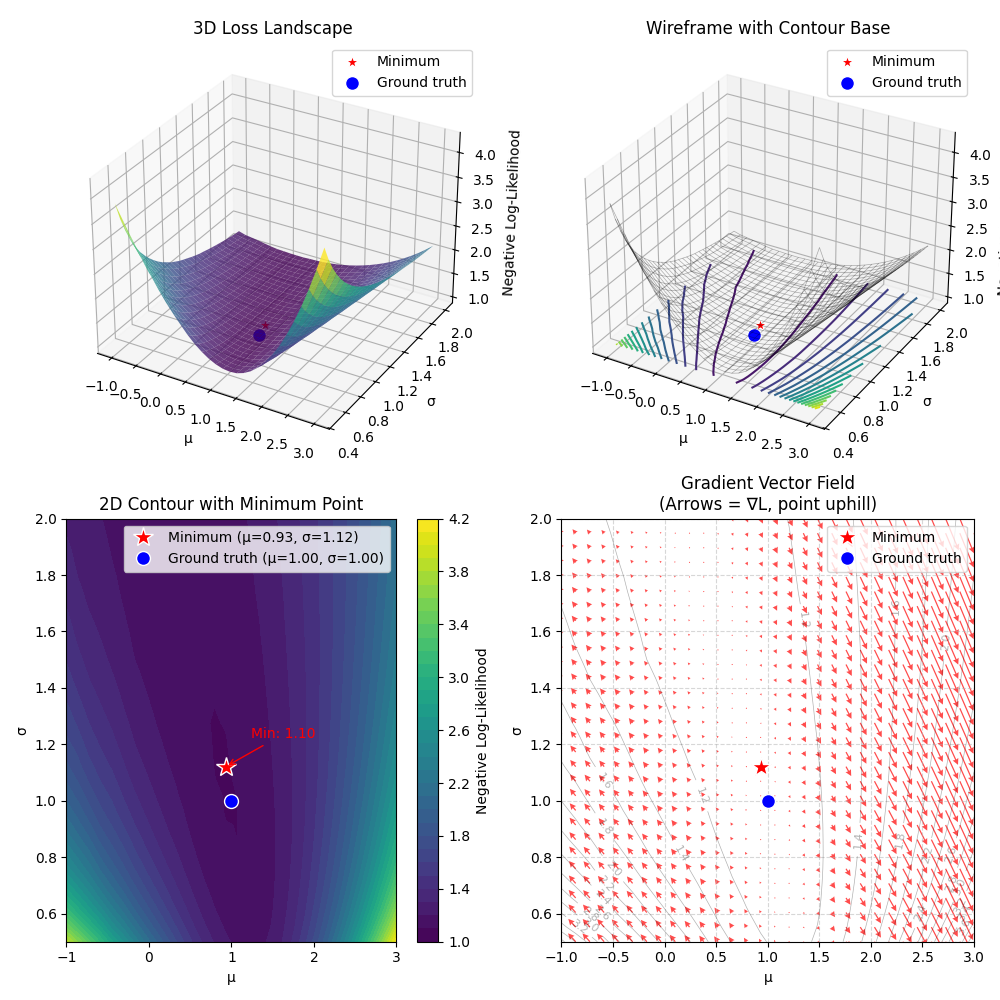

In [205]:
# === Parameter grids ===
mu_values = ch.linspace(-1.0, 3.0, 30)  # Increased resolution
sigma_values = ch.linspace(0.5, 2.0, 30)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

# DATA 
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=False)
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
MU_GRAD = np.zeros_like(MU)
SIGMA_GRAD = ch.zeros_like(SIGMA) 
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        var = ch.Tensor([[SIGMA[i, j]]])
        loss, grad = trunc_nll(MU[i, j][...,None], var, data)
        Z[i, j] = loss
        MU_GRAD[i, j] = grad[1]
        SIGMA_GRAD[i, j] = grad[0]

# Find the minimum point
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu = MU[min_idx]
min_sigma = SIGMA[min_idx]
min_loss = Z[min_idx]

# === Analysis ===
print(f"Ground truth: μ={true_mu.item():.3f}, σ={true_var.sqrt().item():.3f}")
print(f"Minimum found: μ={min_mu:.3f}, σ={min_sigma:.3f}, loss={min_loss:.3f}")
print(f"\nLoss at ground truth: {trunc_nll(true_mu, true_var, data)[0]:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(true_mu, true_var, data)[0] - min_loss:.3f}")

# === Create 3D visualization ===
fig = plt.figure(figsize=(10, 10))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(221, projection='3d')
surf = ax1.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax1.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax1.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax1.set_xlabel('μ')
ax1.set_ylabel('σ')
ax1.set_zlabel('Negative Log-Likelihood')
ax1.set_title('3D Loss Landscape')
ax1.legend()

# Plot 2: 3D wireframe plot
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_wireframe(MU, SIGMA, Z, color='black', alpha=0.3, linewidth=0.5)
contour = ax2.contour(MU, SIGMA, Z, levels=15, offset=np.min(Z) - 0.1, cmap='viridis')
ax2.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax2.set_xlabel('μ')
ax2.set_ylabel('σ')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('Wireframe with Contour Base')
ax2.legend()

# Plot 3: Heatmap with minimum point
ax3 = fig.add_subplot(223)
contourf = ax3.contourf(MU, SIGMA, Z, levels=30, cmap='viridis')
plt.colorbar(contourf, ax=ax3, label='Negative Log-Likelihood')

# Mark minimum and ground truth
ax3.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', 
        label=f'Minimum (μ={min_mu:.2f}, σ={min_sigma:.2f})')
ax3.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, 
        markeredgecolor='white', label=f'Ground truth (μ={true_mu.item():.2f}, σ={true_var.sqrt().item():.2f})')

# Add text annotation for the minimum point
ax3.annotate(f'Min: {min_loss:.2f}', 
            xy=(min_mu, min_sigma), 
            xytext=(min_mu+0.3, min_sigma+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax3.set_xlabel('μ')
ax3.set_ylabel('σ')
ax3.set_title('2D Contour with Minimum Point')
ax3.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(224)

# Plot quiver
Q = ax4.quiver(MU, SIGMA, MU_GRAD, SIGMA_GRAD,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(MU, SIGMA, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax4.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax4.set_xlabel('μ')
ax4.set_ylabel('σ')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Two Dimensional Gaussian

In [206]:
# === Ground truth parameters ===
dims = 2
true_mu = ch.ones(dims)
true_var = ch.eye(dims)
true_T = ch.inverse(true_var)
true_v = true_T @ true_mu

print(f'true mean: {true_mu.tolist()}')
print(f'true covariance: {true_var.tolist()}')

true mean: [1.0, 1.0]
true covariance: [[1.0, 0.0], [0.0, 1.0]]


acceptance rate: 0.7048
Observed mean (x): [[1.0119706392288208, 1.0048928260803223]]


<IPython.core.display.Javascript object>


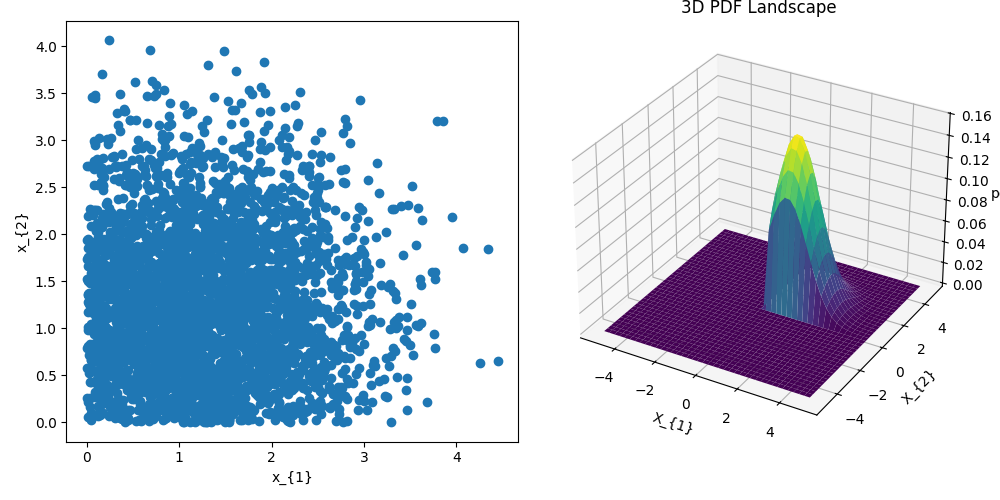

In [207]:
M = MultivariateNormal(ch.zeros(dims), ch.eye(dims))
SAMPLES = M.sample([100000])

# === Synthetic truncated dataset ===
dist = MultivariateNormal(true_mu, true_var)
samples = dist.sample((5000,))
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=True)
# === Truncation region ===
def phi(z):
    # Keep only samples where both coordinates > 0
    return (z > 0).prod(dim=-1, keepdim=True)
mask = phi(samples)
S = samples[mask.nonzero()[:,0]]
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

acceptance_rate = S.size(0) / samples.size(0)
print(f'acceptance rate: {acceptance_rate}')

x_obs = samples.mean(0, keepdim=True) # empirical mean as observed sample
print(f"Observed mean (x): {x_obs.tolist()}")

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax1.scatter(S[:,0], S[:,1])
ax1.set_xlabel('x_{1}')
ax1.set_ylabel('x_{2}')

x_ = ch.linspace(-5.0, 5.0, 40)
y_ = ch.linspace(-5.0, 5.0, 40)
X, Y = ch.meshgrid(x_, y_)

coords = ch.stack([X, Y], dim=-1)
coords_flat = coords.reshape(-1, 2)

pdfs = ch.exp(dist.log_prob(coords_flat))[...,None]
mask = phi(coords_flat)

truncated_pdfs = (pdfs * mask).reshape(X.shape)   
        
ax2 = fig.add_subplot(122, projection='3d')

ax2.plot_surface(X, Y, truncated_pdfs,cmap='viridis',linewidth=0)
ax2.set_xlabel('X_{1}')
ax2.set_ylabel('X_{2}')
ax2.set_zlabel('pdf')
ax2.set_title('3D PDF Landscape')

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


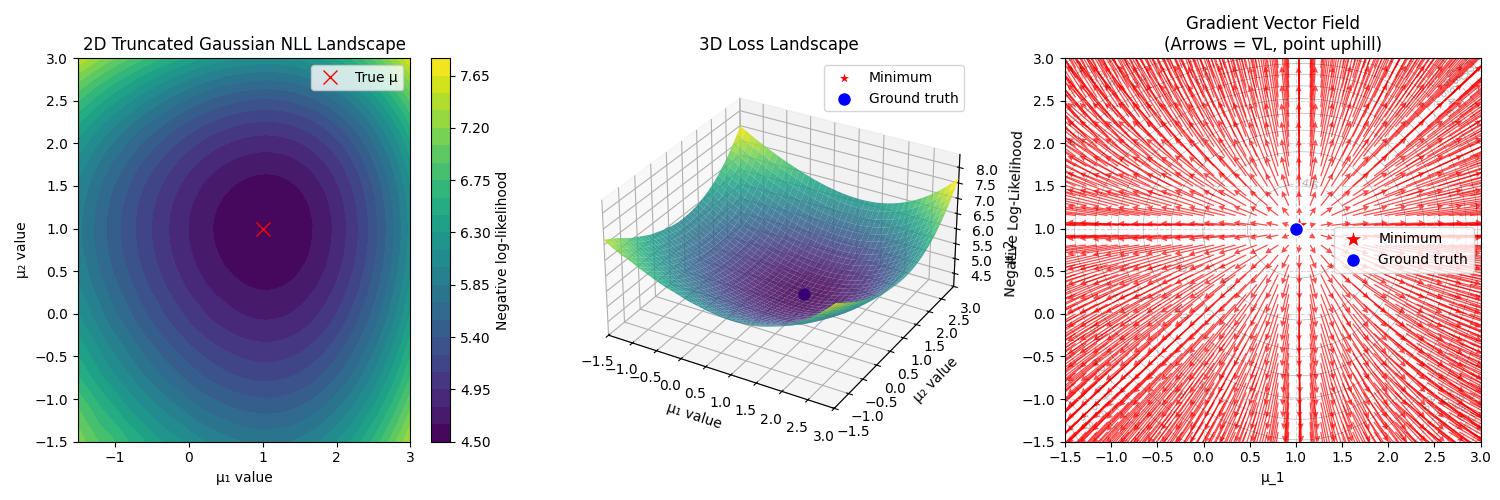


Loss at ground truth: 4.505
Loss at minimum: 4.505
Difference: 0.000


In [208]:
# === Parameter grid for μ₁ and μ₂ ===
mu1_vals = ch.linspace(-1.5, 3.0, 40)
mu2_vals = ch.linspace(-1.5, 3.0, 40)
MU1, MU2 = ch.meshgrid(mu1_vals, mu2_vals)

Z = np.zeros_like(MU1)
MU1_GRAD = ch.zeros_like(MU1)
MU2_GRAD = ch.zeros_like(MU2)
for i in range(len(mu2_vals)):
    for j in range(len(mu1_vals)):
        mu_vec = ch.tensor([MU1[i, j], MU2[i, j]])
        loss, grad = trunc_nll(mu_vec, true_var, data, known_cov=True)
        Z[i, j] = loss
        MU1_GRAD[i, j] = grad[dims**2]
        MU2_GRAD[i, j] = grad[dims**2 + 1]
        
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu_1, min_mu_2 = MU1[min_idx], MU2[min_idx]
min_loss = Z[min_idx]

fig = plt.figure(figsize=(15, 5))

# === 2D contour plot ===
ax1 = fig.add_subplot(131)
cp = ax1.contourf(MU1, MU2, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("2D Truncated Gaussian NLL Landscape")
ax1.set_xlabel("μ₁ value")
ax1.set_ylabel("μ₂ value")

# mark the ground truth
ax1.plot(true_mu[0].item(), true_mu[1].item(), 'rx', markersize=10, label="True μ")
ax1.legend()

# === 3D surface plot ===
ax2 = fig.add_subplot(132, projection='3d')
surf = ax2.plot_surface(MU1, MU2, Z, cmap='viridis', alpha=0.85,
                        linewidth=0, antialiased=True)

# plot key points
ax2.scatter([min_mu_1], [min_mu_2], [min_loss],
            color='red', s=100, label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_mu[0].item()], [true_mu[1].item()], [np.min(Z)],
            color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')

# formatting
ax2.set_xlabel('μ₁ value')
ax2.set_ylabel('μ₂ value')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('3D Loss Landscape')
ax2.legend()

# fix clipping
ax2.set_box_aspect((1, 1, 0.6))  # prevents z from being squashed
ax2.set_xlim(MU1.min(), MU1.max())
ax2.set_ylim(MU2.min(), MU2.max())
ax2.set_zlim(Z.min() - 0.1 * abs(Z.min()), Z.max() + 0.1 * abs(Z.max()))

# Plot 3: Gradient
ax3 = fig.add_subplot(133)

# Plot quiver
Q = ax3.quiver(MU1, MU2, MU1_GRAD, MU2_GRAD,
               color='red', alpha=0.7, width=0.003, scale=5, headwidth=5)

# Add contour of loss for context
contour = ax3.contour(MU1, MU2, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax3.plot(min_mu_1, min_mu_2, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax3.plot(true_mu[0].item(), true_mu[1].item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax3.set_xlabel('μ_1')
ax3.set_ylabel('μ_2')
ax3.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# === Additional analysis ===
print(f"\nLoss at ground truth: {trunc_nll(true_mu, true_var, data, known_cov=True)[0]:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(true_mu, true_var, data, known_cov=True)[0] - min_loss:.3f}")

/tmp/ipykernel_73367/2087447220.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  min_idx = np.unravel_index(np.argmin(Z_mu_sigma), Z_mu_sigma.shape)


<IPython.core.display.Javascript object>


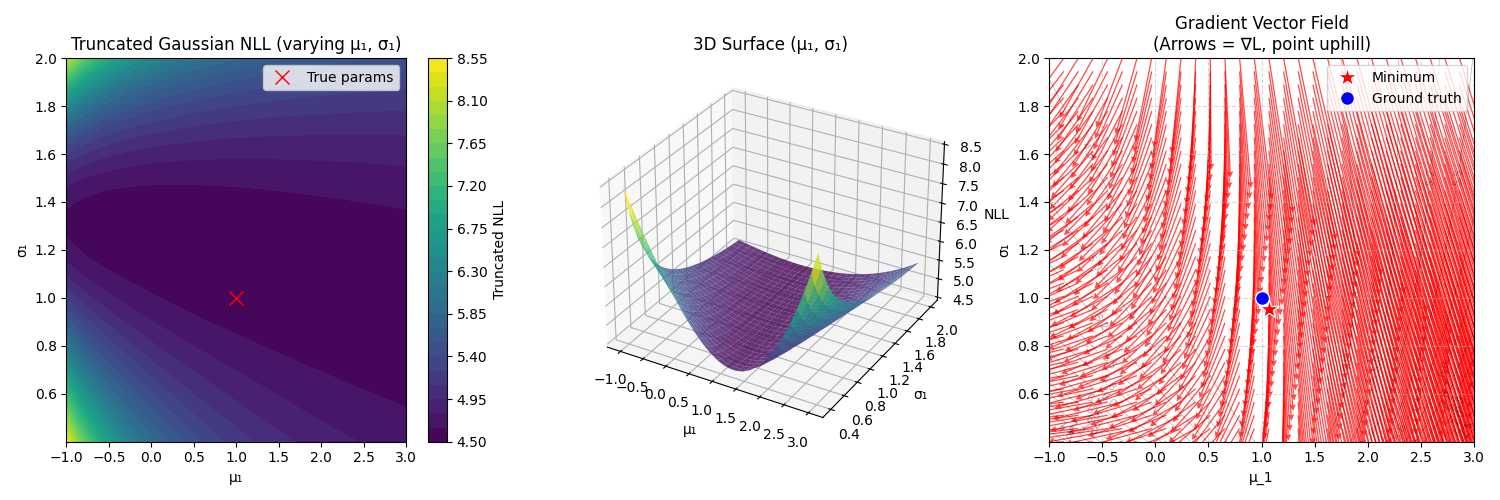


Loss at ground truth: 4.505
Loss at minimum: 4.504
Difference: 0.001


In [209]:
# ==== Vary μ₁ and σ₁ (fix μ₂, σ₂) ====
mu1_vals = ch.linspace(-1, 3, 30)
sigma1_vals = ch.linspace(0.4, 2.0, 30)
MU1, SIGMA1 = ch.meshgrid(mu1_vals, sigma1_vals)
Z_mu_sigma = ch.zeros_like(MU1)
GRAD_MU1 = ch.zeros_like(MU1)
GRAD_SIGMA1 = ch.zeros_like(SIGMA1)

sigma2_fixed = 1.0

for i in range(len(sigma1_vals)):
    for j in range(len(mu1_vals)):
        mu = ch.tensor([MU1[i, j], true_mu[1]])
        Sigma = ch.diag(ch.tensor([SIGMA1[i, j], sigma2_fixed]))
        loss, grad = trunc_nll(mu, Sigma, data)
        Z_mu_sigma[i, j] = loss
        GRAD_MU1[i, j] = grad[4]
        GRAD_SIGMA1[i, j] = grad[0]  
        
min_idx = np.unravel_index(np.argmin(Z_mu_sigma), Z_mu_sigma.shape)
min_mu_1, min_sigma_1 = MU1[min_idx], SIGMA1[min_idx]
min_loss = Z_mu_sigma[min_idx]

# ==== Visualization ====
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 3, 1)
cp = ax1.contourf(mu1_vals, sigma1_vals, Z_mu_sigma, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Truncated NLL")
ax1.plot(true_mu[0], 1.0, "rx", markersize=10, label="True params")
ax1.set_title("Truncated Gaussian NLL (varying μ₁, σ₁)")
ax1.set_xlabel("μ₁")
ax1.set_ylabel("σ₁")
ax1.legend()

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(MU1, SIGMA1, Z_mu_sigma, cmap="viridis", alpha=0.8, linewidth=0)
ax2.set_xlabel("μ₁")
ax2.set_ylabel("σ₁")
ax2.set_zlabel("NLL")
ax2.set_title("3D Surface (μ₁, σ₁)")

# Plot 3: Gradient
ax3 = fig.add_subplot(133)

# Plot quiver
Q = ax3.quiver(MU1, SIGMA1, GRAD_MU1, GRAD_SIGMA1,
               color='red', alpha=0.7, width=0.003, scale=5, headwidth=5)

# Add contour of loss for context
contour = ax3.contour(MU1, SIGMA1, Z_mu_sigma, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax3.plot(min_mu_1, min_sigma_1, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax3.plot(true_mu[0].item(), 1.0, 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax3.set_xlabel('μ_1')
ax3.set_ylabel('σ₁')
ax3.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# === Additional analysis ===
print(f"\nLoss at ground truth: {trunc_nll(true_mu, true_var, data)[0]:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(true_mu, true_var, data)[0] - min_loss:.3f}")

# 10 Dimensional Gaussians

In [210]:
dims = 10
true_mu = ch.randn(dims) 
true_Sigma = 10.0 * ch.eye(dims)
dist = MultivariateNormal(true_mu, true_Sigma)

print(f'true mu: {true_mu.tolist()}')
print(f'true Sigma: {true_Sigma.tolist()}')

true mu: [-0.6793522834777832, -0.29200279712677, 0.6887385845184326, 0.5470297932624817, -0.8693369626998901, 0.6630869507789612, 0.07226573675870895, 0.22025729715824127, 1.8993091583251953, -0.26380616426467896]
true Sigma: [[10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0]]


# Random Matrix Projection

In [211]:
dist = MultivariateNormal(true_mu, true_Sigma)
samples = dist.sample([10000])
# === Truncation region ===
def phi(z):
    # Keep only samples, where norm of the sample is larger than 4.5
    return samples.norm(dim=1, keepdim=True) > 4.5
mask = phi(samples)
S = samples[mask.nonzero()[:,0]]
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)
acceptance_rate = S.size(0) / samples.size(0)
x_obs = samples.mean(0, keepdim=True) # empirical mean as observed sample

print(f"Observed mean (x): {x_obs.tolist()}")
print(f"Total samples: {samples.shape[0]}")
print(f"Truncated samples: {S.shape[0]}")
print(f"Acceptance rate: {S.shape[0] / samples.shape[0]:.4f}")
print(f"Min 10D norm in truncated set: {S.norm(dim=1).min().item():.3f}")
print(f"Max 10D norm: {S.norm(dim=1).max().item():.3f}")

# Project with a random matrix
W = ch.randn(10, 2)
S_2d = S @ W
samples_full_2d = samples_full @ W

projected_norms = np.linalg.norm(S_2d, axis=1)
R_eff = projected_norms.min()  # or use percentile
print(f"Effective 2D radius (min): {R_eff:.2f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Full vs truncated in 2D PCA space
ax1.scatter(samples_full_2d[:, 0], samples_full_2d[:, 1], 
           s=1, alpha=0.3, label='Full Gaussian', color='lightgray')
ax1.scatter(S_2d[:, 0], S_2d[:, 1], 
           s=5, alpha=0.7, label='Truncated (||x|| > 7.0)', color='red')
ax1.set_title('PCA Projection (10D → 2D)')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of projected norms
ax2.hist(projected_norms, bins=50, color='red', alpha=0.7)
ax2.axvline(R_eff, color='black', linestyle='--', label=f'Min norm = {R_eff:.2f}')
ax2.set_xlabel('Projected ||x|| in 2D')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of 2D Norms')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Observed mean (x): [[-0.7139546871185303, -0.3021812438964844, 0.6240119338035583, 0.5488901138305664, -0.8719347715377808, 0.6540548801422119, 0.028148654848337173, 0.20599767565727234, 1.8123400211334229, -0.2751624584197998]]
Total samples: 10000
Truncated samples: 9975
Acceptance rate: 0.9975
Min 10D norm in truncated set: 4.506
Max 10D norm: 19.066


NameError: name 'samples_full' is not defined

# Marginzalized Projection 

<IPython.core.display.Javascript object>


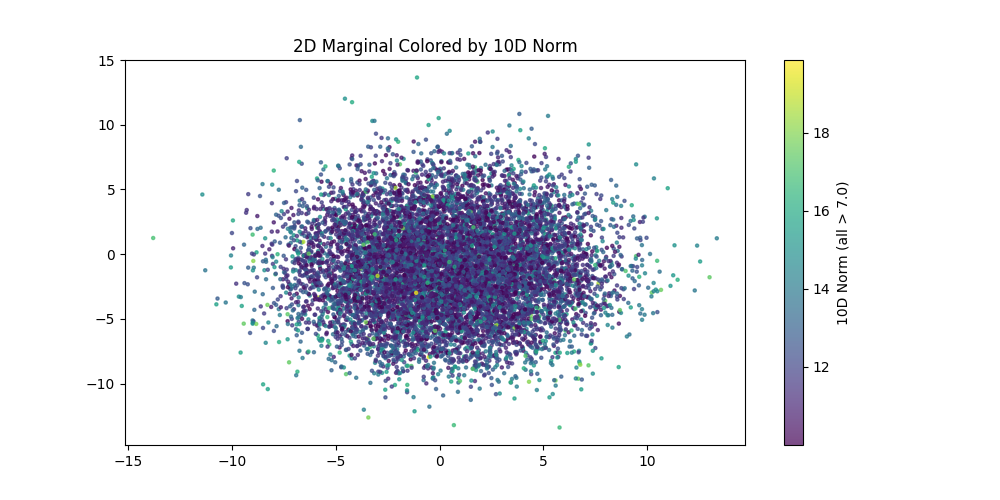

In [121]:
x_marg = S[:, :2].cpu()
norms_10d = S.norm(dim=1).cpu()

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
fig1 = ax1.scatter(x_marg[:, 0], x_marg[:, 1], c=norms_10d, s=5, alpha=0.7)
plt.colorbar(fig1, ax=ax1, label='10D Norm (all > 7.0)')
ax1.set_title('2D Marginal Colored by 10D Norm')
plt.show()

In [ ]:
# Vary mu[0] and sigma[0], fix others
mu0_vals = ch.linspace(true_mu[0] - 2, true_mu[0] + 2, 30)
sigma0_vals = ch.linspace(0.5, 2.0, 30)
MU0, SIGMA0 = ch.meshgrid(mu0_vals, sigma0_vals)

Z = np.zeros((len(sigma0_vals), len(mu0_vals)))
GRAD_MU0 = np.zeros_like(Z)
GRAD_SIGMA0 = np.zeros_like(Z)

for i in range(len(sigma0_vals)):
    for j in range(len(mu0_vals)):
        # Build full mu and Sigma
        mu = true_mu.clone()
        mu[0] = MU0[i, j]
        
        sigma = true_sigma.clone()
        sigma[0] = SIGMA0[i, j]
        Sigma = ch.diag(sigma ** 2)
        
        loss, grad = trunc_nll(mu, Sigma, data, known_cov=False)
        Z[i, j] = loss
        
        # Extract ∂L/∂μ₀ and ∂L/∂σ₀
        dL_dv0 = grad[dims*dims + 0]           # ∂L/∂v₀
        dL_dT00 = grad[0]                      # ∂L/∂T₀₀ (since T is diagonal, T₀₀ is first)
        
        T00 = 1.0 / (sigma[0] ** 2)
        dL_dmu0 = dL_dv0 * T00
        dL_dsigma0 = dL_dT00 * (-2.0 / (sigma[0] ** 3))
        
        GRAD_MU0[i, j] = dL_dmu0
        GRAD_SIGMA0[i, j] = dL_dsigma0